In [2]:
# ============================================================
# ALGORITMO GENÉTICO PARA OPTIMIZACIÓN DE HIPERPARÁMETROS
# Dataset: Mushroom Classification (UCI / Kaggle)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/drive/MyDrive/APRENDIZAJE MAQUINA/mushrooms.csv')
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('class', axis=1).values
y = df['class'].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Dataset cargado: {X.shape[0]} muestras, {X.shape[1]} características")
print(f"Clases: {np.unique(y)}  (0=comestible, 1=venenoso)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset cargado: 8124 muestras, 22 características
Clases: [0 1]  (0=comestible, 1=venenoso)


In [3]:

# =============================================================
# REPRESENTACIÓN (paso 1 del ciclo AG)
# Cromosoma = lista de 4 genes, cada gen es un hiperparámetro:
#   Gen 0 → n_estimators  (número de árboles)
#   Gen 1 → max_depth      (profundidad máxima del árbol)
#   Gen 2 → min_samples_split
#   Gen 3 → max_features   (fracción de features por split)
# =============================================================

PARAM_GRID = {
    'n_estimators':       [10, 20, 30, 50, 75, 100, 150, 200],
    'max_depth':          [2, 4, 6, 8, 10, None],
    'min_samples_split':  [2, 4, 6, 8, 10, 15, 20],
    'max_features':       ['sqrt', 'log2', 0.3, 0.5, 0.7]
}
PARAM_KEYS = list(PARAM_GRID.keys())

def decode_chromosome(chromosome):
    """Convierte índices del cromosoma en valores reales de hiperparámetros."""
    params = {}
    for i, key in enumerate(PARAM_KEYS):
        idx = chromosome[i] % len(PARAM_GRID[key])   # índice dentro de la lista
        params[key] = PARAM_GRID[key][idx]
    return params

# Ejemplo visual del cromosoma
ejemplo = [2, 3, 1, 2]
print("Cromosoma ejemplo:", ejemplo)
print("Hiperparámetros decodificados:", decode_chromosome(ejemplo))

Cromosoma ejemplo: [2, 3, 1, 2]
Hiperparámetros decodificados: {'n_estimators': 30, 'max_depth': 8, 'min_samples_split': 4, 'max_features': 0.3}


In [4]:
# 1: INICIALIZACIÓN ────────────────────────

def initialize_population(pop_size):
    """
    Crea pop_size cromosomas aleatorios.
    Cada gen es un entero que indexa la lista de valores del hiperparámetro.
    """
    population = []
    for _ in range(pop_size):
        chrom = [random.randint(0, len(PARAM_GRID[k]) - 1) for k in PARAM_KEYS]
        population.append(chrom)
    return population

pop = initialize_population(6)
print("Población inicial (6 individuos):")
for i, c in enumerate(pop):
    print(f"  Ind {i}: genes={c}  →  {decode_chromosome(c)}")

Población inicial (6 individuos):
  Ind 0: genes=[2, 1, 1, 4]  →  {'n_estimators': 30, 'max_depth': 4, 'min_samples_split': 4, 'max_features': 0.7}
  Ind 1: genes=[3, 3, 4, 1]  →  {'n_estimators': 50, 'max_depth': 8, 'min_samples_split': 10, 'max_features': 'log2'}
  Ind 2: genes=[0, 4, 4, 0]  →  {'n_estimators': 10, 'max_depth': 10, 'min_samples_split': 10, 'max_features': 'sqrt'}
  Ind 3: genes=[2, 2, 0, 4]  →  {'n_estimators': 30, 'max_depth': 6, 'min_samples_split': 2, 'max_features': 0.7}
  Ind 4: genes=[7, 4, 1, 3]  →  {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 4, 'max_features': 0.5}
  Ind 5: genes=[0, 5, 1, 3]  →  {'n_estimators': 10, 'max_depth': None, 'min_samples_split': 4, 'max_features': 0.5}


In [5]:
# 2: FUNCIÓN DE APTITUD ────────────────────

def fitness(chromosome, X, y, cv):
    """
    Entrena un RandomForest con los hiperparámetros del cromosoma
    y devuelve la accuracy promedio en validación cruzada.
    """
    params = decode_chromosome(chromosome)
    model = RandomForestClassifier(
        n_estimators      = params['n_estimators'],
        max_depth         = params['max_depth'],
        min_samples_split = params['min_samples_split'],
        max_features      = params['max_features'],
        random_state      = 42,
        n_jobs            = -1
    )
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    return scores.mean()

# Prueba rápida
test_chrom = [4, 3, 0, 0]          # n_est=75, max_depth=8, min_split=2, sqrt
fit_val = fitness(test_chrom, X, y, cv)
print(f"Fitness del cromosoma de prueba {decode_chromosome(test_chrom)}: {fit_val:.4f}")

Fitness del cromosoma de prueba {'n_estimators': 75, 'max_depth': 8, 'min_samples_split': 2, 'max_features': 'sqrt'}: 1.0000


In [6]:
# 3: SELECCIÓN por torneo ──────────────────

def tournament_selection(population, fitnesses, k=3):
    """Selecciona un individuo por torneo de tamaño k."""
    competidores = random.sample(range(len(population)), k)
    ganador      = max(competidores, key=lambda i: fitnesses[i])
    return population[ganador][:]   # copia

# 4: CRUZAMIENTO un punto  ─────────────────

def single_point_crossover(p1, p2, prob=0.8):
    """Cruzamiento de un punto con probabilidad `prob`."""
    if random.random() < prob:
        punto = random.randint(1, len(p1) - 1)
        hijo1 = p1[:punto] + p2[punto:]
        hijo2 = p2[:punto] + p1[punto:]
        return hijo1, hijo2
    return p1[:], p2[:]

# 5: MUTACIÓN (paso 6) ─────────────────────────────

def mutate(chromosome, prob=0.2):
    """
    Con probabilidad `prob` por gen, reemplaza el índice por uno
    aleatorio dentro del rango válido de ese hiperparámetro.
    """
    mutante = chromosome[:]
    for i, key in enumerate(PARAM_KEYS):
        if random.random() < prob:
            mutante[i] = random.randint(0, len(PARAM_GRID[key]) - 1)
    return mutante

In [7]:
# 6 : CICLO PRINCIPAL DEL AG ────────────────────────

def genetic_algorithm_hyperopt(
    X, y,
    pop_size      = 20,
    n_generations = 15,
    crossover_prob = 0.8,
    mutation_prob  = 0.2,
    elitism        = 2,
    verbose        = True
):
    """
    Algoritmo genético completo para optimización de hiperparámetros.
    Devuelve el mejor cromosoma y el historial de fitness.
    """
    # ── Inicialización ──────────────────────────────────────
    population = initialize_population(pop_size)
    best_fitness_hist = []
    avg_fitness_hist  = []
    best_chrom        = None
    best_fit          = -np.inf

    if verbose:
        print(f"{'Gen':>4} | {'Mejor Acc':>10} | {'Prom Acc':>10} | Mejor config")
        print("-" * 70)

    for gen in range(n_generations):

        # ── Evaluación (fitness) ────────────────────────────
        fitnesses = [fitness(c, X, y, cv) for c in population]

        gen_best = max(fitnesses)
        gen_avg  = np.mean(fitnesses)
        best_fitness_hist.append(gen_best)
        avg_fitness_hist.append(gen_avg)

        # Guardar el mejor global
        best_idx = int(np.argmax(fitnesses))
        if fitnesses[best_idx] > best_fit:
            best_fit   = fitnesses[best_idx]
            best_chrom = population[best_idx][:]

        if verbose:
            cfg = decode_chromosome(best_chrom)
            print(f"{gen+1:>4} | {gen_best:>10.4f} | {gen_avg:>10.4f} | "
                  f"n_est={cfg['n_estimators']}, depth={cfg['max_depth']}, "
                  f"min_split={cfg['min_samples_split']}, feat={cfg['max_features']}")

        # ── Elitismo ────────────────────────────────────────
        elite_idx = np.argsort(fitnesses)[-elitism:]
        nueva_pop = [population[i][:] for i in elite_idx]

        # ── Selección, cruzamiento y mutación ───────────────
        while len(nueva_pop) < pop_size:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)
            h1, h2 = single_point_crossover(p1, p2, crossover_prob)
            h1 = mutate(h1, mutation_prob)
            h2 = mutate(h2, mutation_prob)
            nueva_pop.extend([h1, h2])

        # ── TERMINACIÓN: reemplazar población ───────────────
        population = nueva_pop[:pop_size]

    return best_chrom, best_fitness_hist, avg_fitness_hist


# ── EJECUCIÓN ───────────────────────────────────────────────
print("=" * 70)
print("  AG - OPTIMIZACIÓN DE HIPERPARÁMETROS | Mushroom Dataset")
print("=" * 70)

mejor_chrom, hist_mejor, hist_prom = genetic_algorithm_hyperopt(
    X, y, pop_size=20, n_generations=15,
    crossover_prob=0.8, mutation_prob=0.2, elitism=2
)

  AG - OPTIMIZACIÓN DE HIPERPARÁMETROS | Mushroom Dataset
 Gen |  Mejor Acc |   Prom Acc | Mejor config
----------------------------------------------------------------------
   1 |     1.0000 |     0.9793 | n_est=10, depth=None, min_split=6, feat=0.5
   2 |     1.0000 |     0.9948 | n_est=10, depth=None, min_split=6, feat=0.5
   3 |     1.0000 |     0.9957 | n_est=10, depth=None, min_split=6, feat=0.5
   4 |     1.0000 |     0.9964 | n_est=10, depth=None, min_split=6, feat=0.5
   5 |     1.0000 |     0.9995 | n_est=10, depth=None, min_split=6, feat=0.5
   6 |     1.0000 |     1.0000 | n_est=10, depth=None, min_split=6, feat=0.5
   7 |     1.0000 |     0.9950 | n_est=10, depth=None, min_split=6, feat=0.5
   8 |     1.0000 |     0.9994 | n_est=10, depth=None, min_split=6, feat=0.5
   9 |     1.0000 |     1.0000 | n_est=10, depth=None, min_split=6, feat=0.5
  10 |     1.0000 |     1.0000 | n_est=10, depth=None, min_split=6, feat=0.5
  11 |     1.0000 |     0.9997 | n_est=10, depth=None, 

In [8]:
# RESULTADOS FINALES ────────────────────────────

mejores_params = decode_chromosome(mejor_chrom)
print("\n✔  Mejores hiperparámetros encontrados por el AG:")
for k, v in mejores_params.items():
    print(f"   {k:22s} = {v}")
print(f"\n   Fitness (accuracy CV) = {max(hist_mejor):.4f}")

# Comparación: hiperparámetros por defecto vs AG
modelo_default = RandomForestClassifier(random_state=42, n_jobs=-1)
modelo_ag      = RandomForestClassifier(
    n_estimators      = mejores_params['n_estimators'],
    max_depth         = mejores_params['max_depth'],
    min_samples_split = mejores_params['min_samples_split'],
    max_features      = mejores_params['max_features'],
    random_state      = 42,
    n_jobs            = -1
)

acc_default = cross_val_score(modelo_default, X, y, cv=cv).mean()
acc_ag      = cross_val_score(modelo_ag,      X, y, cv=cv).mean()

print(f"\n📊 Comparación final:")
print(f"   Accuracy con hiperparámetros por defecto : {acc_default:.4f}")
print(f"   Accuracy con hiperparámetros del AG      : {acc_ag:.4f}")
print(f"   Mejora                                   : {(acc_ag - acc_default)*100:+.2f}%")


✔  Mejores hiperparámetros encontrados por el AG:
   n_estimators           = 10
   max_depth              = None
   min_samples_split      = 6
   max_features           = 0.5

   Fitness (accuracy CV) = 1.0000

📊 Comparación final:
   Accuracy con hiperparámetros por defecto : 1.0000
   Accuracy con hiperparámetros del AG      : 1.0000
   Mejora                                   : +0.00%


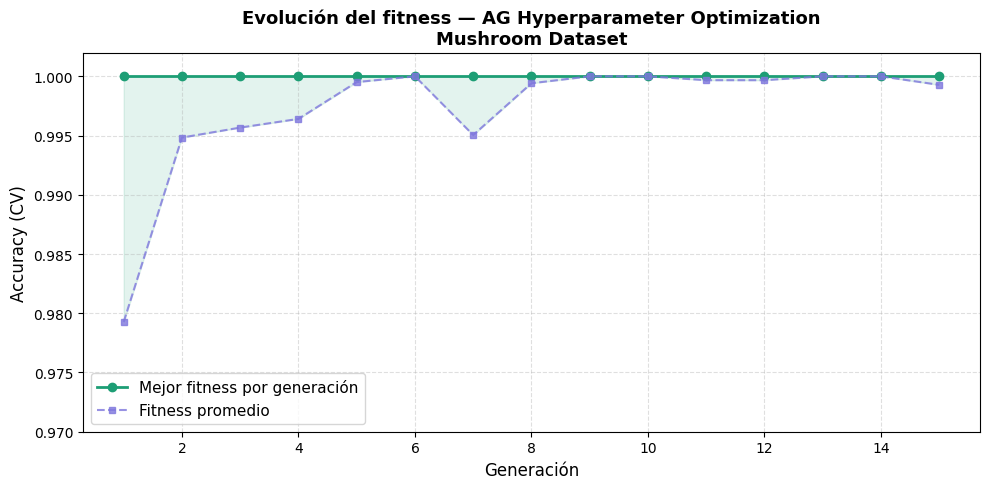

Gráfica guardada como ag_hyperopt_evolucion.png


In [9]:
#GRÁFICA DE EVOLUCIÓN ──────────────────────────

generaciones = list(range(1, len(hist_mejor) + 1))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(generaciones, hist_mejor, 'o-',  color='#1D9E75', linewidth=2,
        markersize=6, label='Mejor fitness por generación')
ax.plot(generaciones, hist_prom,  's--', color='#7F77DD', linewidth=1.5,
        markersize=5, alpha=0.8, label='Fitness promedio')
ax.fill_between(generaciones, hist_prom, hist_mejor,
                alpha=0.12, color='#1D9E75')

ax.set_xlabel('Generación', fontsize=12)
ax.set_ylabel('Accuracy (CV)', fontsize=12)
ax.set_title('Evolución del fitness — AG Hyperparameter Optimization\nMushroom Dataset',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0.97, 1.002)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('ag_hyperopt_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada como ag_hyperopt_evolucion.png")